In [2]:
import torch
import os
import glob
import random
import numpy as np
from PIL import Image
import decord
import cv2
import supervision as sv
from tqdm import tqdm
import matplotlib.pyplot as plt
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # Set to the GPU you want to use

print("CUDA_HOME:", os.environ.get("CUDA_HOME"))
print("torch.version.cuda:", torch.version.cuda)
print("nvcc path:", os.popen("which nvcc").read().strip())
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration

CUDA_HOME: None
torch.version.cuda: 12.8
nvcc path: /usr/local/cuda-12.8/bin/nvcc
[2025-07-31 20:37:03,800] [INFO] [real_accelerator.py:254:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/home/ubuntu/miniconda3/envs/spinflow/compiler_compat/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/home/ubuntu/miniconda3/envs/spinflow/compiler_compat/ld: warning: librt.so.1, needed by /usr/local/cuda-12.8/lib64/libcufile.so, not found (try using -rpath or -rpath-link)
/home/ubuntu/miniconda3/envs/spinflow/compiler_compat/ld: warning: libpthread.so.0, needed by /usr/local/cuda-12.8/lib64/libcufile.so, not found (try using -rpath or -rpath-link)
/home/ubuntu/miniconda3/envs/spinflow/compiler_compat/ld: warning: libstdc++.so.6, needed by /usr/local/cuda-12.8/lib64/libcufile.so, not found (try using -rpath or -rpath-link)
/home/ubuntu/miniconda3/envs/spinflow/compiler_compat/ld: warning: libm.so.6, needed by /usr/local/cuda-12.8/lib64/libcufile.so, not found (try using -rpath or -rpath-link)
/home/ubuntu/miniconda3/envs/spinflow/compiler_compat/ld: /usr/local/cuda-12.8/lib64/libcufile.so: undefined reference to `std::runtime_error::~runtim

[2025-07-31 20:37:05,021] [INFO] [logging.py:107:log_dist] [Rank -1] [TorchCheckpointEngine] Initialized with serialization = False


In [3]:
from diffusers import DiffusionPipeline, AutoencoderKL, UNet2DConditionModel

# blip3o imports
from qwen_vl_utils import process_vision_info
from blip3o.model.builder import load_pretrained_model
from blip3o.utils import disable_torch_init
from blip3o.mm_utils import tokenizer_image_token, process_images, get_model_name_from_path

OpenCLIP not installed


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

In [4]:
from sam2.build_sam import build_sam2_video_predictor, build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from sam2.sam2_video_predictor import SAM2VideoPredictor
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection 

In [5]:
# Initialize the VLM model and processor
device = "cuda" if torch.cuda.is_available() else "cpu"
processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-7B-Instruct")

repo_id = "BLIP3o/BLIP3o-Model-8B"
model_name = get_model_name_from_path(repo_id)
diffusion_path = model_name + "/diffusion-decoder"

disable_torch_init()
tokenizer, multi_model, context_len = load_pretrained_model(repo_id, device, model_name)

loading configuration file preprocessor_config.json from cache at /home/ubuntu/.cache/huggingface/hub/models--Qwen--Qwen2.5-VL-7B-Instruct/snapshots/cc594898137f460bfe9f0759e9844b3ce807cfb5/preprocessor_config.json
loading configuration file preprocessor_config.json from cache at /home/ubuntu/.cache/huggingface/hub/models--Qwen--Qwen2.5-VL-7B-Instruct/snapshots/cc594898137f460bfe9f0759e9844b3ce807cfb5/preprocessor_config.json
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Image processor Qwen2VLImageProcessor {
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.48145466,
    0.4578275,
    0.40821073
  ],
  "image_processor_type": "Qwen2VLImageProce

 latent query size torch.Size([1, 64, 3584])


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

Some weights of the model checkpoint at BLIP3o/BLIP3o-Model-8B were not used when initializing blip3oQwenForInferenceLM: ['model.gen_vision_tower.vision_tower.model.blocks.0.attn.proj.bias', 'model.gen_vision_tower.vision_tower.model.blocks.0.attn.proj.weight', 'model.gen_vision_tower.vision_tower.model.blocks.0.attn.qkv.bias', 'model.gen_vision_tower.vision_tower.model.blocks.0.attn.qkv.weight', 'model.gen_vision_tower.vision_tower.model.blocks.0.mlp.fc1.bias', 'model.gen_vision_tower.vision_tower.model.blocks.0.mlp.fc1.weight', 'model.gen_vision_tower.vision_tower.model.blocks.0.mlp.fc2.bias', 'model.gen_vision_tower.vision_tower.model.blocks.0.mlp.fc2.weight', 'model.gen_vision_tower.vision_tower.model.blocks.0.norm1.bias', 'model.gen_vision_tower.vision_tower.model.blocks.0.norm1.weight', 'model.gen_vision_tower.vision_tower.model.blocks.0.norm2.bias', 'model.gen_vision_tower.vision_tower.model.blocks.0.norm2.weight', 'model.gen_vision_tower.vision_tower.model.blocks.1.attn.proj.bi

In [6]:
def set_global_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def process_image(prompt: str, img: Image.Image) -> str:
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": img},
            {"type": "text", "text": prompt},
        ],
    }]
    text_prompt_for_qwen = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text_prompt_for_qwen],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    ).to(device)
    generated_ids = multi_model.generate(**inputs, max_new_tokens=1024)
    input_token_len = inputs.input_ids.shape[1]
    generated_ids_trimmed = generated_ids[:, input_token_len:]
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]
    return output_text


In [7]:
# Initialize Grounding Dino SAM
# pip install timm==1.0.13
torch.autocast(device_type=device, dtype=torch.bfloat16).__enter__()
if torch.cuda.get_device_properties(0).major >= 8:
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

sam2_dir = "/home/ubuntu/playground/spinflow/external/Grounded-SAM-2"
sam2_checkpoint = f"{sam2_dir}/checkpoints/sam2.1_hiera_large.pt"
model_cfg = f"configs/sam2.1/sam2.1_hiera_l.yaml"

video_predictor = build_sam2_video_predictor(model_cfg, sam2_checkpoint)
sam2_image_model = build_sam2(model_cfg, sam2_checkpoint)
image_predictor = SAM2ImagePredictor(sam2_image_model)

model_id = "IDEA-Research/grounding-dino-tiny"
dino_processor = AutoProcessor.from_pretrained(model_id)
grounding_model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(device)

loading configuration file preprocessor_config.json from cache at /home/ubuntu/.cache/huggingface/hub/models--IDEA-Research--grounding-dino-tiny/snapshots/a2bb814dd30d776dcf7e30523b00659f4f141c71/preprocessor_config.json
loading configuration file preprocessor_config.json from cache at /home/ubuntu/.cache/huggingface/hub/models--IDEA-Research--grounding-dino-tiny/snapshots/a2bb814dd30d776dcf7e30523b00659f4f141c71/preprocessor_config.json
Image processor GroundingDinoImageProcessor {
  "do_convert_annotations": true,
  "do_normalize": true,
  "do_pad": true,
  "do_rescale": true,
  "do_resize": true,
  "format": "coco_detection",
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "GroundingDinoImageProcessor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "pad_size": null,
  "processor_class": "GroundingDinoProcessor",
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "longest_edge": 1333,
    "shortest_edge": 800
  }
}

lo

In [8]:
def detect_masks_single(
    image_np: np.ndarray,
    prompt: str,
    image_predictor: SAM2ImagePredictor,
    grounding_model: AutoModelForZeroShotObjectDetection,
    processor: AutoProcessor,
    device: str = "cuda"
):
    """
    Detects masks in a single image based on the provided prompt.
    
    Args:
        image (Image.Image): The input image.
        prompt (str): The prompt for mask detection.
        video_predictor (SAM2ImagePredictor): The SAM2 image predictor.
        grounding_model (AutoModelForZeroShotObjectDetection): The grounding model for object detection.
        dino_processor (AutoProcessor): The processor for the grounding model.
        device (str): The device to run the model on ("cuda" or "cpu").
    
    Returns:
        dictionary: A dictionary containing the detected masks and their bounding boxes.
    """
    img = Image.fromarray(image_np).convert("RGB")  # Convert to PIL Image
    if "," in prompt:
        prompt = prompt.replace(",", ".")

    #2 Get bbox detection seeds
    inputs = processor(images=img, text=prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = grounding_model(**inputs)
    
    results = dino_processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        box_threshold=0.5,
        text_threshold=0.5,
        target_sizes=[img.size[::-1]]
    )
    image_predictor.set_image(np.array(img.convert("RGB")))

    input_boxes = results[0]["boxes"].cpu().numpy()
    objects = results[0]["labels"]  

    #3 Extract SAM2 masks
    masks, scores, logits = image_predictor.predict(
        point_coords=None,
        point_labels=None,
        box=input_boxes,
        multimask_output=False,
    )
    if masks.ndim == 3:
        masks = masks[None]
        scores = scores[None]
        logits = logits[None]
    elif masks.ndim == 4:
        masks = masks.squeeze(1)

    return {
        "masks": masks,
        "scores": scores,
        "logits": logits,
        "boxes": input_boxes,
        "labels": objects,
    }

def track_masks(
    video_np: np.ndarray,
    objects: list,
    masks: np.ndarray,
    video_path: str,
    video_predictor: SAM2VideoPredictor,
):
    inference_state = video_predictor.init_state(video_path)
    ann_frame_idx = 0  # the frame index we interact with
    ann_obj_id = 1

    PROMPT_TYPE_FOR_VIDEO = "mask"
    for object_id, (label, mask) in enumerate(zip(objects, masks), start=1):
        labels = np.ones((1), dtype=np.int32)
        _, out_obj_ids, out_mask_logits = video_predictor.add_new_mask(
            inference_state=inference_state,
            frame_idx=ann_frame_idx,
            obj_id=object_id,
            mask=mask
        )

    video_segments = {}  # video_segments contains the per-frame segmentation results
    for out_frame_idx, out_obj_ids, out_mask_logits in video_predictor.propagate_in_video(inference_state):
        video_segments[out_frame_idx] = {
            out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
            for i, out_obj_id in enumerate(out_obj_ids)
        }
    
    return video_segments

def draw_masks_single(
    image: np.ndarray,
    masks: np.ndarray,
    boxes: np.ndarray,
    labels,
    alpha: float = 0.5
) -> np.ndarray:
    """
    Draws masks, bounding boxes, and labels on a single RGB image using supervision.

    Args:
        image:  H×W×3 uint8 RGB image.
        masks:  (N, H, W) bool or float mask array.
        boxes:  (N, 4) array of [xmin, ymin, xmax, ymax] in pixel coords.
        labels: length-N list of class names (strings).
        alpha:  mask transparency (0–1).

    Returns:
        Annotated H×W×3 uint8 image.
    """
    img = image.copy()

    # Ensure mask is boolean
    masks_bool = masks > 0.5 if masks.dtype != bool else masks
    N = masks_bool.shape[0]

    # Convert boxes to int pixel coords
    boxes_int = boxes.astype(int)

    # Give each detection a numeric ID 1..N
    class_ids = np.arange(1, N + 1, dtype=np.int32)

    # Build a supervision Detections object
    detections = sv.Detections(
        xyxy=boxes_int,
        mask=masks_bool,
        class_id=class_ids,
    )

    # Create the annotators
    mask_annotator  = sv.MaskAnnotator()
    box_annotator   = sv.BoxAnnotator()
    label_annotator = sv.LabelAnnotator(text_position=sv.Position.CENTER)
    
    # Draw in this order: masks → boxes → labels
    out = mask_annotator.annotate(scene=img,                        detections=detections)
    out = box_annotator.annotate(scene=out,                         detections=detections)
    out = label_annotator.annotate(scene=out, detections=detections, labels=list(labels))

    return out

Selected video: ../../data/fai_processed/output_rides_2025-05-06-15-50-00/ride_ferrite1_2025-05-06-15-55-12_0/seq_5633/front_camera.mp4
Output text:
door, mat, brick, plant
Split text:
['door, mat, brick, plant']
masks shape  (2, 480, 640)
Closest object captions:
navigate to mat, go to mat, head towards mat, move towards mat, approach mat, walk to mat, drive to mat, enter mat, step on mat, reach mat


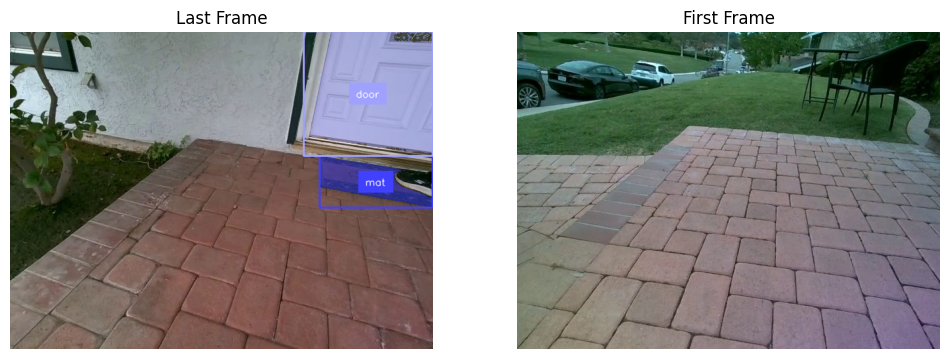

In [9]:
%matplotlib inline

# Detect interesting objects of interest in the image
# prompt = "Describe any large objects and landmarks that we can navigate to in the image. Do not describe terrains like road, street, and sidewalk. Output the nouns in a comma separated list format."
prompt = """
Describe unique and specific objects and landmarks that are visible in both images
Do not describe terrains like road, street, and sidewalk. 
Output the nouns in a comma separated list format.
If no objects are visible in both images, output an empty string.
"""

# prompt = """
# Describe the terrain that the robot is staying on. 
# Describe the entities that the robot is navigating directly to (e.g. stairs, door, trash can. driveway).
# The generated text should be in the format:
# <action> on <staying_on_terrain>,
# <action> the <avoiding terrain>,
# <action> to <navigating_to_entity1>, <navigating_to_entity2>, ... 
# Vary the <action> keyword with the appropriate robot action based on the context.
# Do not output any other text.
# """
# set_global_seed(seed=42)

# Read video with decord and select the first frame
# video_path="../../data/fai_processed/output_rides_2025-07-02-16-33-00/ride_ferrite3_2025-07-02-16-39-39_0/seq_214_294/front_camera.mp4"
# Select random front_camera.mp4 from the directory
video_dir = "../../data/fai_processed/"
videos = glob.glob(os.path.join(video_dir, "**", "front_camera.mp4"), recursive=True)
video_path = random.choice(videos)
print(f"Selected video: {video_path}")

decord.bridge.set_bridge("torch")
vr = decord.VideoReader(str(video_path))

# img = Image.fromarray(img).convert("RGB")  # Convert to PIL Image
video_th = vr.get_batch(range(0, 1))
video_np = video_th.numpy()
last_img_np = video_np[0]
# img = Image.fromarray(video_np[0]).convert("RGB")  # Convert to PIL Image

first_img = vr.get_batch(range(len(vr) - 1, len(vr)))
first_img_np = first_img.numpy()[0]

stacked_img = np.stack([last_img_np, first_img_np], axis=0)
img = Image.fromarray(stacked_img[0]).convert("RGB")  # Convert to PIL Image

object_captions = process_image(prompt, img)

print(f"Output text:\n{object_captions.strip()}")
split_caption = object_captions.strip().split("\n")
print(f'Split text:\n{split_caption}')

if len(object_captions.strip()) == 0 or object_captions.strip() == "":
    print("No objects detected in the image.")
    exit(0)
detections = detect_masks_single(
    image_np=video_np[-1],
    prompt=object_captions,
    image_predictor=image_predictor,
    grounding_model=grounding_model,
    processor=dino_processor,
    device=device
)

  # Debugging breakpoint
# video_segments = track_masks(
#     video_np=video_np,
#     objects=detections["labels"],
#     masks=detections["masks"],
#     video_path=video_path,
#     video_predictor=video_predictor
# )

last_video_th = vr.get_batch(range(len(vr) - 1, len(vr)))
last_video_np = last_video_th.numpy()
last_img = Image.fromarray(last_video_np[0]).convert("RGB")  # Convert

# Draw detections on the last frame
try:
    if detections["masks"].ndim == 4:
        detections["masks"] = detections["masks"].squeeze(1)
    img = draw_masks_single(
        image=video_np[-1],
        masks=detections["masks"],
        boxes=detections["boxes"],
        labels=detections["labels"]
    )
    img = Image.fromarray(img).convert("RGB")  # Convert to PIL Image
    print("masks shape ", detections["masks"].shape)
except Exception as e:
    print("masks shape ", detections["masks"].shape)
    print(f"Error drawing masks: {e}")

detected_object_captions = ", ".join(detections["labels"])
refine_prompt = f"""
{detected_object_captions.strip()}
Select the closest object from the list above that the robot is navigating to in the format <action> <preposition> <object>. 
Output ten descriptions with the same <object> and different <action> and <prepositions> tokens in a comma separated list format.
If there is not a nearby or clear object, output a blank string.
"""
closest_object_captions = process_image(refine_prompt, img)
print(f"Closest object captions:\n{closest_object_captions.strip()}")

# Plot first and last image side by side
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Last Frame")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(last_img)
plt.title("First Frame")
plt.axis("off")
plt.show()

In [10]:
def create_video_from_images(image_folder, output_video_path, frame_rate=25):
    # define valid extension
    valid_extensions = [".jpg", ".jpeg", ".JPG", ".JPEG", ".png", ".PNG"]
    
    # get all image files in the folder
    image_files = [f for f in os.listdir(image_folder) 
                   if os.path.splitext(f)[1] in valid_extensions]
    image_files.sort()  # sort the files in alphabetical order
    print(image_files)
    if not image_files:
        raise ValueError("No valid image files found in the specified folder.")
    
    # load the first image to get the dimensions of the video
    first_image_path = os.path.join(image_folder, image_files[0])
    first_image = cv2.imread(first_image_path)
    height, width, _ = first_image.shape
    
    # create a video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v') # codec for saving the video
    video_writer = cv2.VideoWriter(output_video_path, fourcc, frame_rate, (width, height))
    
    # write each image to the video
    for image_file in tqdm(image_files):
        image_path = os.path.join(image_folder, image_file)
        image = cv2.imread(image_path)
        video_writer.write(image)
    
    # source release
    video_writer.release()
    print(f"Video saved at {output_video_path}")


In [11]:
# Visualize tracked segmentation mask
save_dir = "./tracking_results"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

ID_TO_OBJECTS = {i: obj for i, obj in enumerate(detections["labels"], start=1)}
video_np = vr.get_batch(range(0, len(vr))).numpy()  # Get all frames in the video

for frame_idx, segments in video_segments.items():
    img = video_np[frame_idx]
    
    object_ids = list(segments.keys())
    masks = list(segments.values())
    masks = np.concatenate(masks, axis=0)

    detections = sv.Detections(
        xyxy=sv.mask_to_xyxy(masks),  # (n, 4)
        mask=masks, # (n, h, w)
        class_id=np.array(object_ids, dtype=np.int32),
    )
    box_annotator = sv.BoxAnnotator()
    annotated_frame = box_annotator.annotate(scene=img.copy(), detections=detections)
    label_annotator = sv.LabelAnnotator()
    annotated_frame = label_annotator.annotate(annotated_frame, detections=detections, labels=[ID_TO_OBJECTS[i] for i in object_ids])
    mask_annotator = sv.MaskAnnotator()
    annotated_frame = mask_annotator.annotate(scene=annotated_frame, detections=detections)
    cv2.imwrite(os.path.join(save_dir, f"annotated_frame_{frame_idx:05d}.jpg"), annotated_frame)

output_video_path = "./frodo_tracking_demo_video.mp4"
create_video_from_images(save_dir, output_video_path)

NameError: name 'video_segments' is not defined